## classifiction matrices 

In [14]:
from sklearn.metrics import confusion_matrix

# Example data
y_true = [0, 1, 0, 1, 0, 1, 1, 0 ,0, 0,]
y_pred = [0, 1, 0, 0, 0, 1, 1, 0, 1, 1]

# Generate the matrix
cm = confusion_matrix(y_true, y_pred)

# Extract counts in the exact order: TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")


TN: 4, FP: 2, FN: 1, TP: 3


In [15]:
confusion_matrix(y_true, y_pred)

array([[4, 2],
       [1, 3]], dtype=int64)

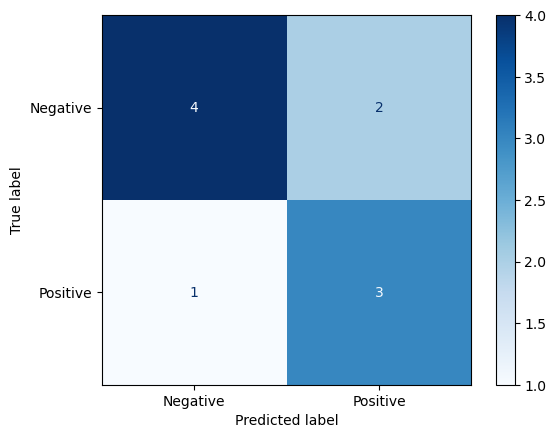

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


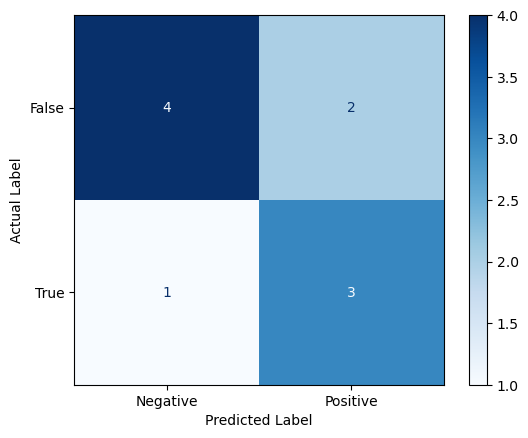

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display labels match the standard 0 (False/Negative) and 1 (True/Positive) order
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['False', 'True'])

# Plot the matrix
disp.plot(cmap=plt.cm.Blues)

# Explicitly override the axis labels for maximum clarity
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Adjust the tick markings to display Positive/Negative on the columns
plt.gca().set_xticklabels(['Negative', 'Positive'])

plt.show()


Verify TN: 4, FP: 2, FN: 1, TP: 3

# Import Librareies


In [4]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,roc_curve

# Import dataset


In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

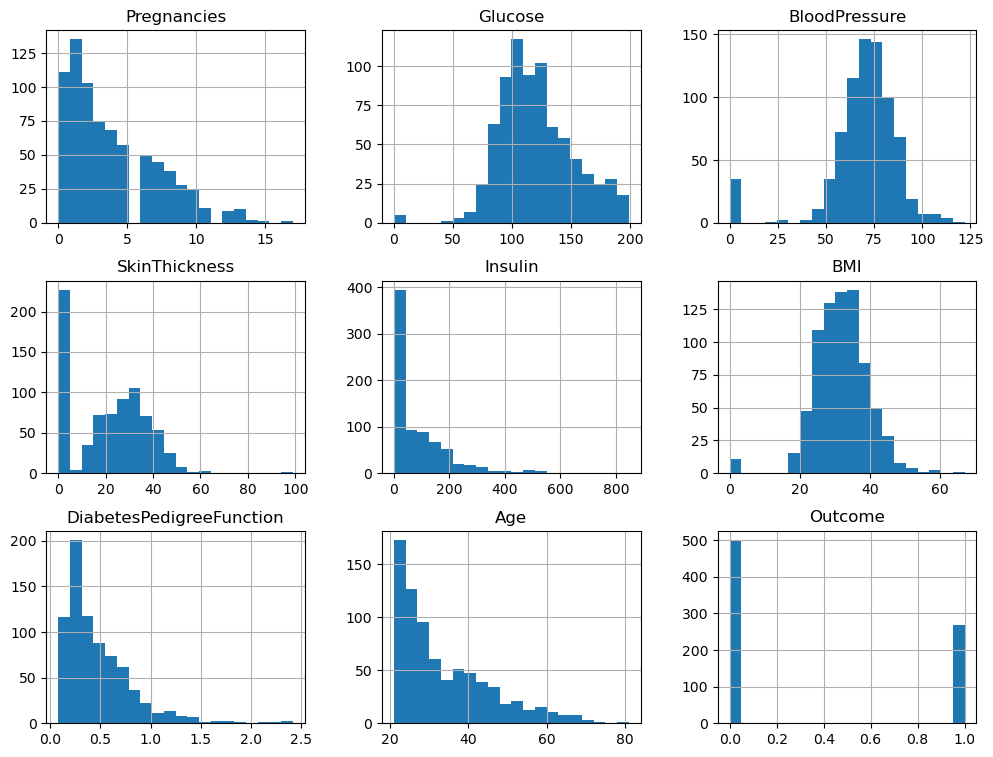

In [9]:
data.hist(bins = 20,figsize=(12,9))


In [10]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# train test split


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# fit logistic reg model


In [12]:
model = LogisticRegression(max_iter=100)
model.fit(X_train,y_train)

c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [14]:
y_scores = model.predict_proba(X_test)[:,1]
y_scores

array([0.049577  , 0.17459229, 0.09368018, 0.25498284, 0.63538417,
       0.11679174, 0.06572134, 0.42179426, 0.04869655, 0.575554  ,
       0.33865873, 0.41297346, 0.69849334, 0.199771  , 0.02003596,
       0.82465329, 0.86647407, 0.03103205, 0.25522343, 0.89481453,
       0.95243029, 0.83473017, 0.1174515 , 0.44678756, 0.08926795,
       0.06885992, 0.65113738, 0.41207704, 0.1786472 , 0.28694262,
       0.24539001, 0.43907742, 0.00943322, 0.24268308, 0.35169407,
       0.96159468, 0.34366778, 0.80914169, 0.29388826, 0.05086734,
       0.18193132, 0.08677586, 0.42233989, 0.18744807, 0.03014615,
       0.03951376, 0.24746915, 0.42778325, 0.10538341, 0.37974579,
       0.99355533, 0.10662134, 0.39085999, 0.76878352, 0.36865685,
       0.45780847, 0.95028632, 0.41972427, 0.39145111, 0.04379361,
       0.37304967, 0.90118964, 0.88170085, 0.88831905, 0.33086909,
       0.06923877, 0.95259343, 0.20066967, 0.2606393 , 0.35467624,
       0.10366125, 0.08175888, 0.45036445, 0.09224804, 0.08651

# evualtion metric


In [15]:
roc_curve(y_test,y_scores)

(array([0.        , 0.        , 0.        , 0.00917431, 0.00917431,
        0.02752294, 0.02752294, 0.0733945 , 0.0733945 , 0.08256881,
        0.08256881, 0.09174312, 0.09174312, 0.10091743, 0.10091743,
        0.11009174, 0.11009174, 0.12844037, 0.12844037, 0.14678899,
        0.14678899, 0.1559633 , 0.1559633 , 0.17431193, 0.17431193,
        0.18348624, 0.18348624, 0.22018349, 0.22018349, 0.30275229,
        0.30275229, 0.35779817, 0.35779817, 0.39449541, 0.39449541,
        0.40366972, 0.40366972, 0.42201835, 0.42201835, 0.53211009,
        0.53211009, 0.5412844 , 0.5412844 , 0.57798165, 0.57798165,
        0.63302752, 0.63302752, 0.66055046, 0.66055046, 0.74311927,
        0.74311927, 0.98165138, 0.98165138, 1.        ]),
 array([0.        , 0.02222222, 0.08888889, 0.08888889, 0.28888889,
        0.28888889, 0.31111111, 0.31111111, 0.33333333, 0.33333333,
        0.37777778, 0.37777778, 0.4       , 0.4       , 0.44444444,
        0.44444444, 0.48888889, 0.48888889, 0.53333333, 0.

In [16]:

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [17]:
thresholds

array([       inf, 0.99355533, 0.95259343, 0.95243029, 0.82465329,
       0.76878352, 0.76178802, 0.6835204 , 0.67511094, 0.67413158,
       0.65113738, 0.65087877, 0.63538417, 0.58617986, 0.575554  ,
       0.56937678, 0.52481885, 0.47005229, 0.46139864, 0.45036445,
       0.43907742, 0.4388323 , 0.42233989, 0.41972427, 0.41297346,
       0.41207704, 0.40480189, 0.37974579, 0.36865685, 0.3101631 ,
       0.30886979, 0.27779582, 0.27208558, 0.25522343, 0.25498284,
       0.24746915, 0.24539001, 0.23659566, 0.22897105, 0.18193132,
       0.1786472 , 0.17459229, 0.17327736, 0.14639828, 0.14074853,
       0.11679174, 0.11499955, 0.11007951, 0.10662134, 0.08926795,
       0.08677586, 0.02003596, 0.01934107, 0.00161126])

# roc curve

In [19]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic (ROC Curve)',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


Now find the threshold value whihc is near to 1 . just sbutract by 1 and minium distance value is your threshold value 

# optimal threshold value

In [20]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)

Optimal threshold is: 0.36865684923208725


In [21]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_scores)

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [22]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [27]:
optimal_idx = np.argmax(lr_tpr - lr_fpr)
optimal_threshold = lr_thresholds[optimal_idx]
print("Optimal logistic regression threshold is:", optimal_threshold)

Optimal logistic regression threshold is: 0.3686601046915037


In [28]:
optimal_idx = np.argmax(svm_tpr - svm_fpr)
optimal_threshold = svm_thresholds[optimal_idx]
print("Optimal svm threshold is:", optimal_threshold)

Optimal svm threshold is: 0.2384529753964208
